In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/rohitpravinlohar/fingerprint-dataset-for-blood-group-classification')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  soham0666


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/rohitpravinlohar/fingerprint-dataset-for-blood-group-classification


100%|██████████| 56.1M/56.1M [00:00<00:00, 162MB/s] 


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale = 1./255,
    validation_split = 0.20
)

train_generator = datagen.flow_from_directory(
    r'/kaggle/working/fingerprint-dataset-for-blood-group-classification/Fingerprint Dataset for Blood Group Classification',
    target_size = (96,103),
    batch_size = 40,
    subset = "training",
    class_mode = 'categorical',
    shuffle = True
)

test_generator = datagen.flow_from_directory(
    r'/kaggle/working/fingerprint-dataset-for-blood-group-classification/Fingerprint Dataset for Blood Group Classification',
    target_size = (96,103),
    batch_size = 40,
    subset = 'validation',
    class_mode = 'categorical',
    shuffle = False
    
)

2026-04-02 17:27:14.170200: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775150834.361213      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775150834.413502      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775150834.857326      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775150834.857373      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775150834.857376      55 computation_placer.cc:177] computation placer alr

Found 4621 images belonging to 8 classes.
Found 1152 images belonging to 8 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout, Activation

model = Sequential()

# Layer 1
model.add(Conv2D(96, kernel_size=(3,3), strides=(1,1), input_shape=(96,103,3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 2
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(BatchNormalization())

# Layer 3
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same'))
model.add(Activation('relu'))

# Layer 4
model.add(Conv2D(384, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))

# Layer 5
model.add(Conv2D(256, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.5))

# Fully Connected Layer 2
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(8, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775150853.029512      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [6]:
model.compile(loss = 'categorical_crossentropy', optimizer = 'adam' , metrics = ['accuracy'])

In [7]:
history = model.fit(train_generator, epochs = 50, validation_data = test_generator)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1775150857.516278     149 service.cc:152] XLA service 0x7b02b0006670 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775150857.516325     149 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775150858.136535     149 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/116 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.1236 - loss: 14.8010

I0000 00:00:1775150867.643045     149 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


116/116 ━━━━━━━━━━━━━━━━━━━━ 32s 161ms/step - accuracy: 0.2097 - loss: 3.7246 - val_accuracy: 0.3082 - val_loss: 1.8692
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.5283 - loss: 1.2857 - val_accuracy: 0.1241 - val_loss: 2.0916
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.7439 - loss: 0.7001 - val_accuracy: 0.3273 - val_loss: 1.7547
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.7875 - loss: 0.5989 - val_accuracy: 0.7066 - val_loss: 0.7863
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.8073 - loss: 0.4995 - val_accuracy: 0.7908 - val_loss: 0.5849
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.8377 - loss: 0.4453 - val_accuracy: 0.7726 - val_loss: 0.5993
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.8390 - loss: 0.4118 - val_accuracy: 0.7318 - val_loss: 0.7245
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.8523 - loss: 0.3901 - val_accuracy: 0.3

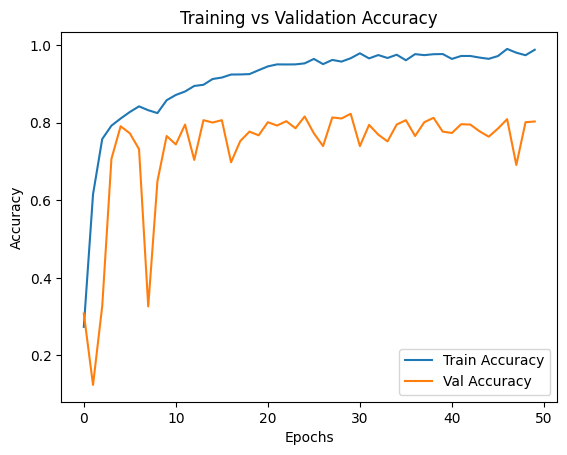

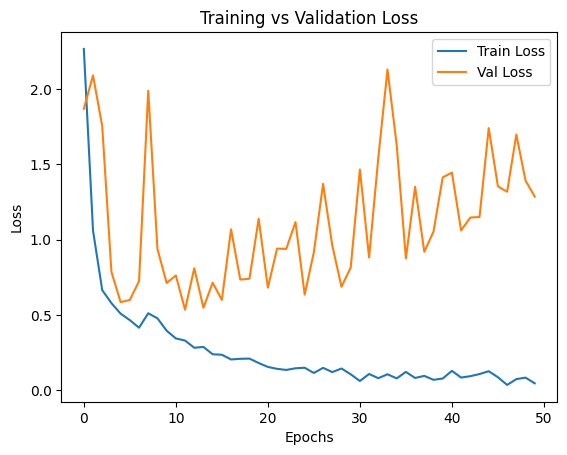

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

In [9]:
accu = model.evaluate(test_generator)[1]

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8152 - loss: 1.2965


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
# Assuming validation_generator is your test/validation generator
# Make sure shuffle=False to match labels correctly
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Predict probabilities
y_pred_probs = model.predict(test_generator, verbose=1)

# Convert probabilities to class indices
y_pred = np.argmax(y_pred_probs, axis=1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step


In [12]:
from sklearn.metrics import classification_report
import numpy as np

# Reset generator to keep order correct
test_generator.reset()

# True labels
y_true = test_generator.classes

# Predictions
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names)

print(report)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
              precision    recall  f1-score   support

          A+       0.90      0.92      0.91       113
          A-       0.68      0.73      0.70       154
         AB+       0.91      0.76      0.83       141
         AB-       0.78      0.74      0.76       152
          B+       0.76      0.79      0.77       130
          B-       0.79      0.91      0.85       149
          O+       0.80      0.89      0.84       170
          O-       0.86      0.69      0.77       143

    accuracy                           0.80      1152
   macro avg       0.81      0.80      0.80      1152
weighted avg       0.81      0.80      0.80      1152



29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


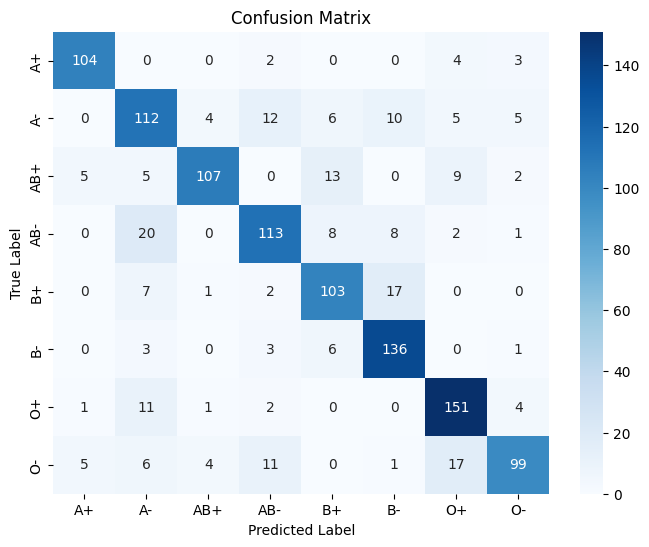

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Reset generator so predictions match labels
test_generator.reset()

# True labels
y_true = test_generator.classes

# Predict probabilities
y_pred_probs = model.predict(test_generator, verbose=1)

# Convert probabilities to class index
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names
class_names = list(test_generator.class_indices.keys())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()